## Teste e Validação dos Métodos de Explicabilidade (XAI)

### Este notebook tem como objetivo testar e validar as implementações orientadas a objetos criadas na pasta `src/xai/`. 

### As classes desenvolvidas encapsulam a lógica matemática dos métodos de XAI, permitindo aplicar no modelo CNN-LSTM e gerar suas representações gráficas. 

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

In [2]:
DATASET_ID = "FD001"

model_path = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_ID}.keras"
x_path = f"../../data/processed_data/X_test_{DATASET_ID}.npz"
y_path = f"../../data/processed_data/y_test_{DATASET_ID}.npz"

idx_teste = 0  # amostra usada em todas as explicações locais deste notebook

In [3]:
sys.path.append(os.path.abspath('../..')) 
from src.xai.xai_baseExplainer import BaseExplainer

#Inicia a classe Base
base = BaseExplainer(model_path, x_path, y_path)

# Testando se as funções base estão funcionando.

In [4]:
print(f"--- TESTE: AMOSTRA {idx_teste} ---")
print(f"Shape retornado: {base.get_instance(idx_teste).shape}")
print(f"RUL Real: {base.get_true_rul(idx_teste)}")
print(f"RUL Predito: {base.get_prediction(idx_teste):.2f}")

--- TESTE: AMOSTRA 0 ---
Shape retornado: (1, 30, 19)
RUL Real: 113
RUL Predito: 120.95


## ShapExplainer

O `ShapExplainer` utiliza os Valores Shapley para medir a contribuição exata de cada variável na decisão da rede neural. Através dele, conseguimos quantificar o impacto isolado de cada **sensor** na predição. 

In [5]:
from src.xai.xai_shapExplainer import ShapExplainer

explainer_shap = ShapExplainer(model_path, x_path, y_path)

In [6]:
print(f"Calculando SHAP para a amostra {idx_teste}...")
shap_values = explainer_shap.explain_instance(idx_teste)

print(f"RUL Real: {explainer_shap.get_true_rul(idx_teste)}")
print(f"RUL Previsto: {explainer_shap.get_prediction(idx_teste):.2f}")
print(f"Shape original dos SHAP values: {shap_values.shape}")

Calculando SHAP para a amostra 0...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(50, 30, 19))']
  warnings.warn(msg)


RUL Real: 113
RUL Previsto: 120.95
Shape original dos SHAP values: (1, 30, 19, 1)


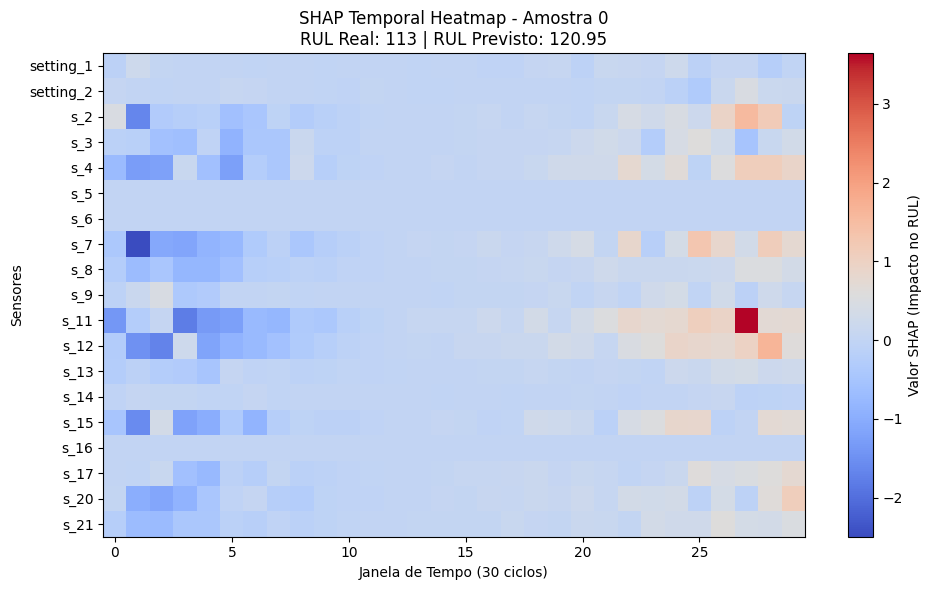

In [7]:
explainer_shap.plot_temporal_heatmap(idx_teste)

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)


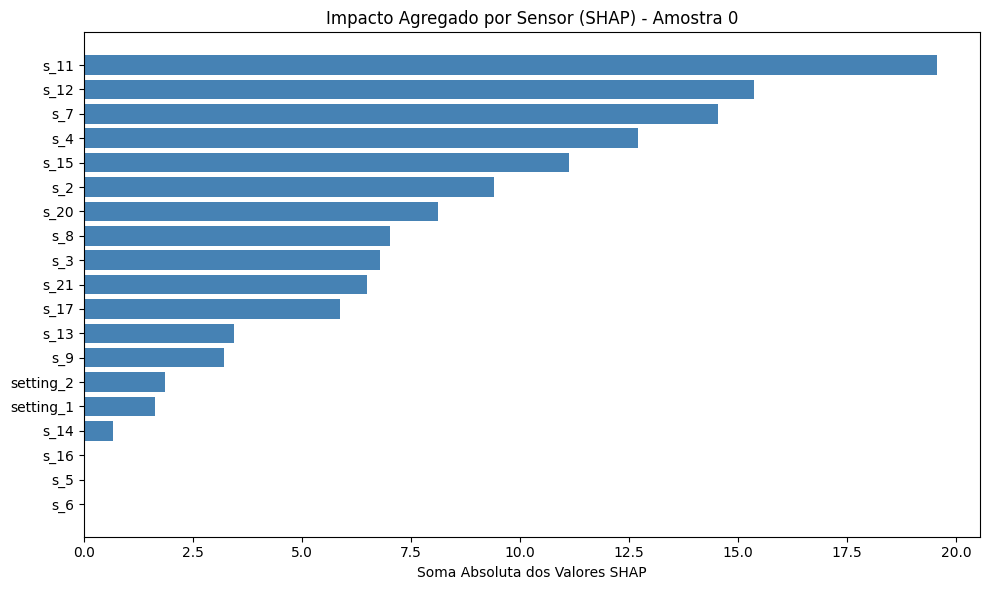

In [8]:
explainer_shap.plot_sensor_importance_bar(idx_teste)

Calculando SHAP para 100 amostras (isso pode levar alguns segundos)...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(100, 30, 19))']
  warnings.warn(msg)
c:\Users\davis\Documents\vscode\Turbofan-Engine-Degradation-Mestrado\src\xai\xai_shapExplainer.py:83: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_2d, instances_2d, feature_names=sensores_labels, show=False)


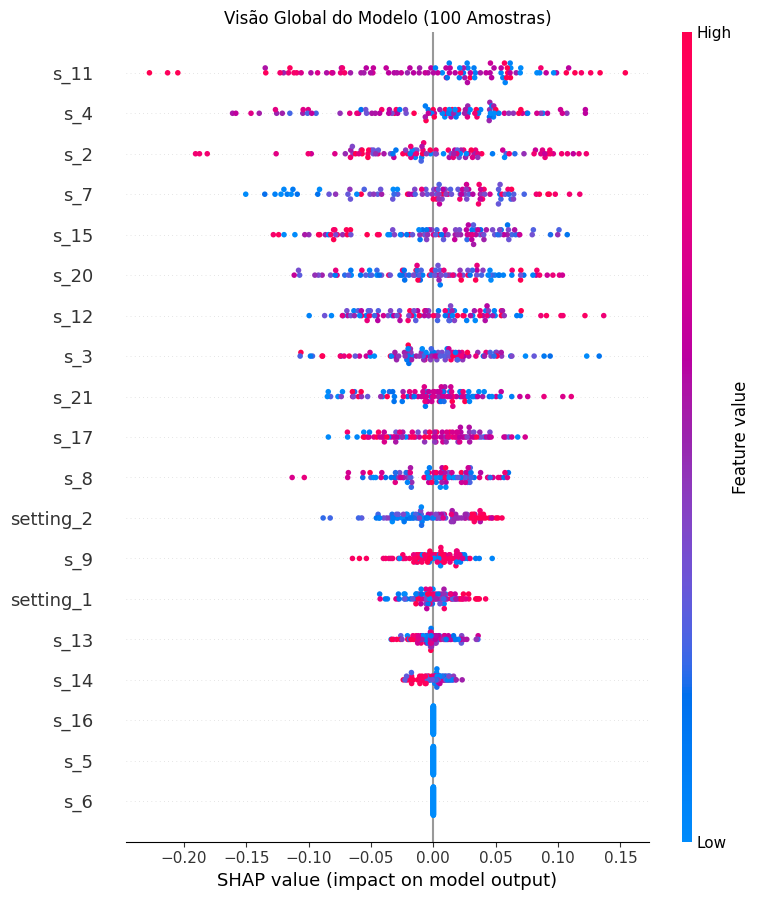

In [9]:
# Testa a visão global (usa por padrão as primeiras 100 amostras do conjunto de teste)
explainer_shap.plot_global_summary()

## LimeExplainer

O `LimeExplainer` aproxima o modelo complexo criando um modelo interpretável mais simples (como uma regressão linear) ao redor de uma predição específica. Ele avalia como pequenas perturbações nos dados afetam a decisão local da rede neural.

In [10]:
from src.xai.xai_limeExplainer import LimeExplainer

lime_explainer = LimeExplainer(model_path, x_path, y_path)

RUL Real: 113 | RUL Previsto: 120.95


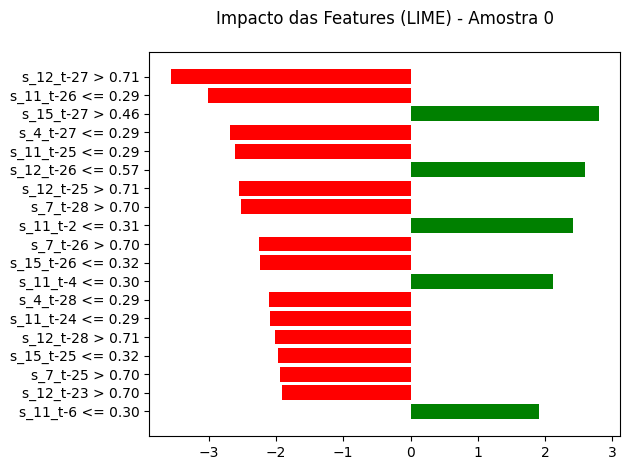

In [11]:
lime_explainer.plot_lime_explanation(idx_teste)

In [12]:
# Desativado por padrão: abre um arquivo .html no navegador, o que não é adequado
# para execução não-interativa (ex.: servidor remoto, CI, "Run All").
# Descomente para inspecionar a explicação LIME interativa localmente.
# lime_explainer.save_and_open_html(idx_teste)

## Integrated Gradients (IG)

O `Integrated Gradients` mede a importância das variáveis calculando a transição matemática de um "estado neutro" (baseline) até a amostra real. Ele acumula os gradientes ao longo desse caminho para atribuir o peso exato de cada entrada na predição.

In [13]:
from src.xai.xai_igExplainer import IntegratedGradientsExplainer

ig_explainer = IntegratedGradientsExplainer(model_path, x_path, y_path)

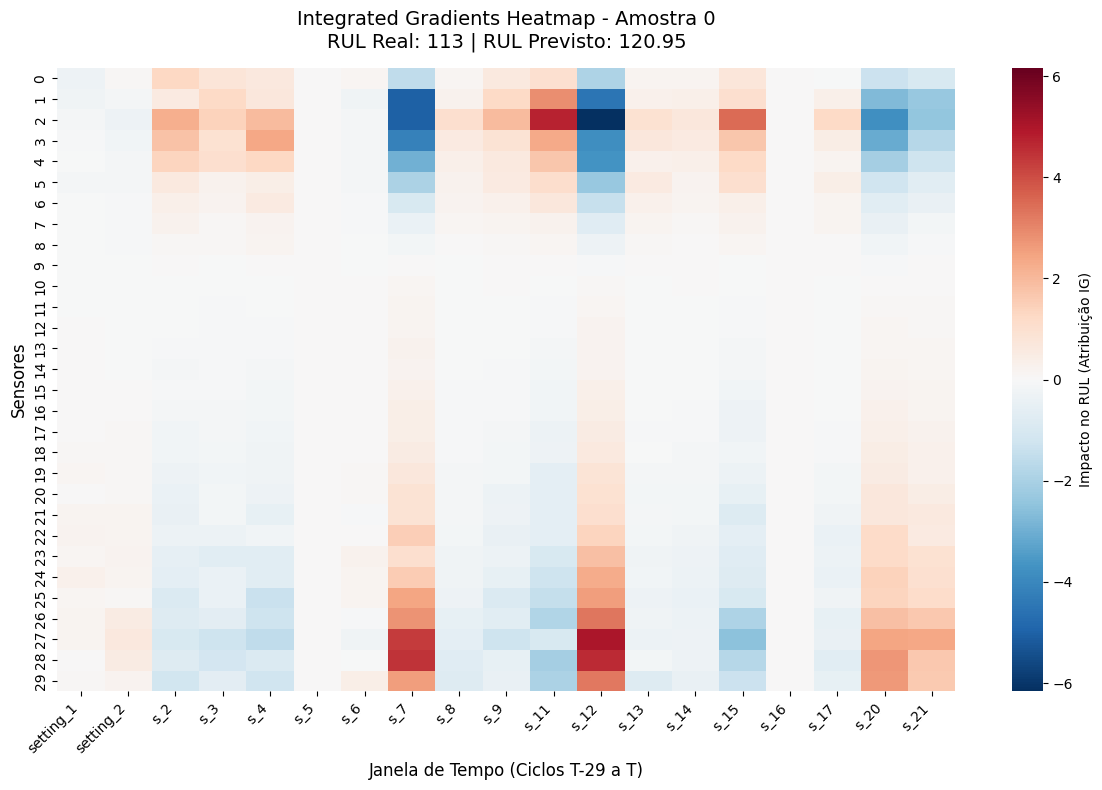

In [14]:
ig_explainer.plot_heatmap(index=0, m_steps=50)

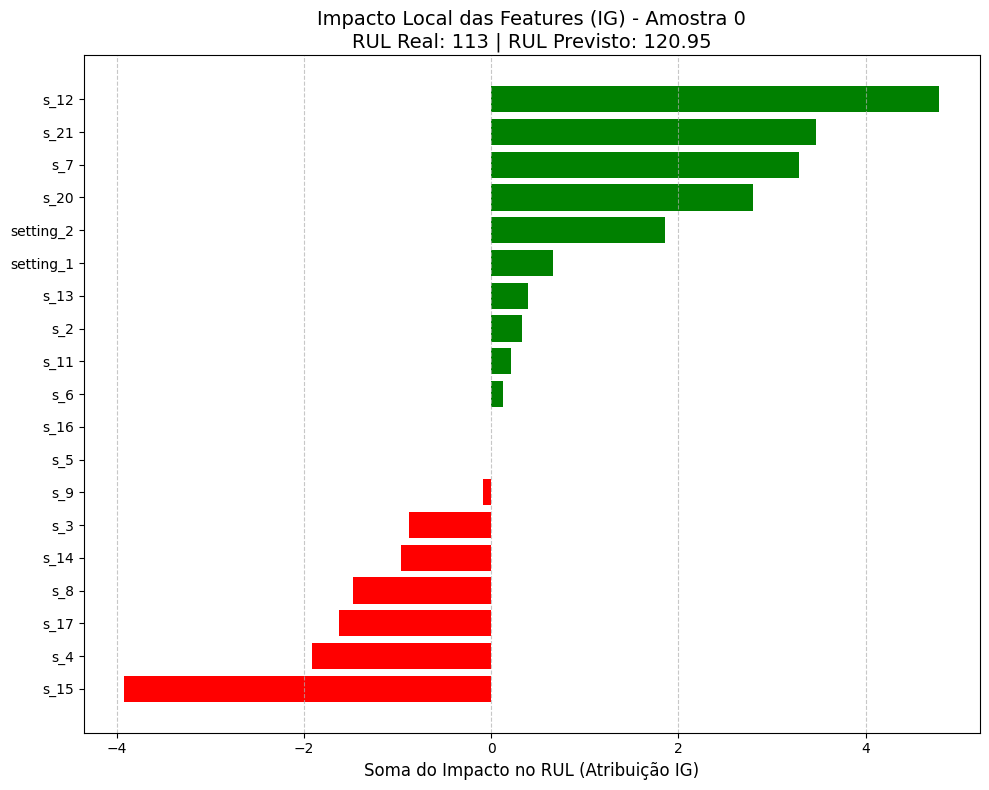

In [15]:
ig_explainer.plot_local_bar(index=0, m_steps=50)

Calculando IG global para 50 amostras. Isso pode levar alguns segundos...


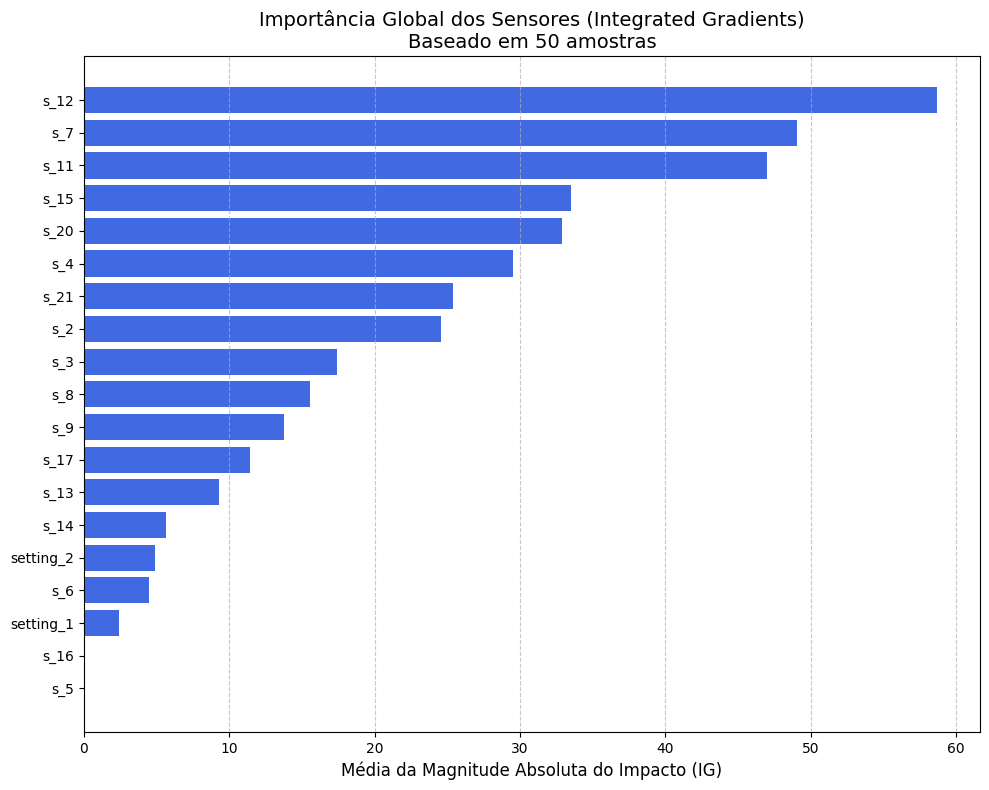

In [16]:
ig_explainer.plot_global_importance(num_samples=50, m_steps=50)

## TimeSHAP

O `TimeSHAP` é uma adaptação do SHAP focada em séries temporais. Ele avalia a importância individual de cada **ciclo de tempo** e ajuda a identificar até que ponto do passado a rede neural realmente presta atenção para realizar a predição.

In [17]:
from src.xai.xai_timeshapExplainer import TimeShapExplainer

timeshap_explainer = TimeShapExplainer(model_path, x_path, y_path)

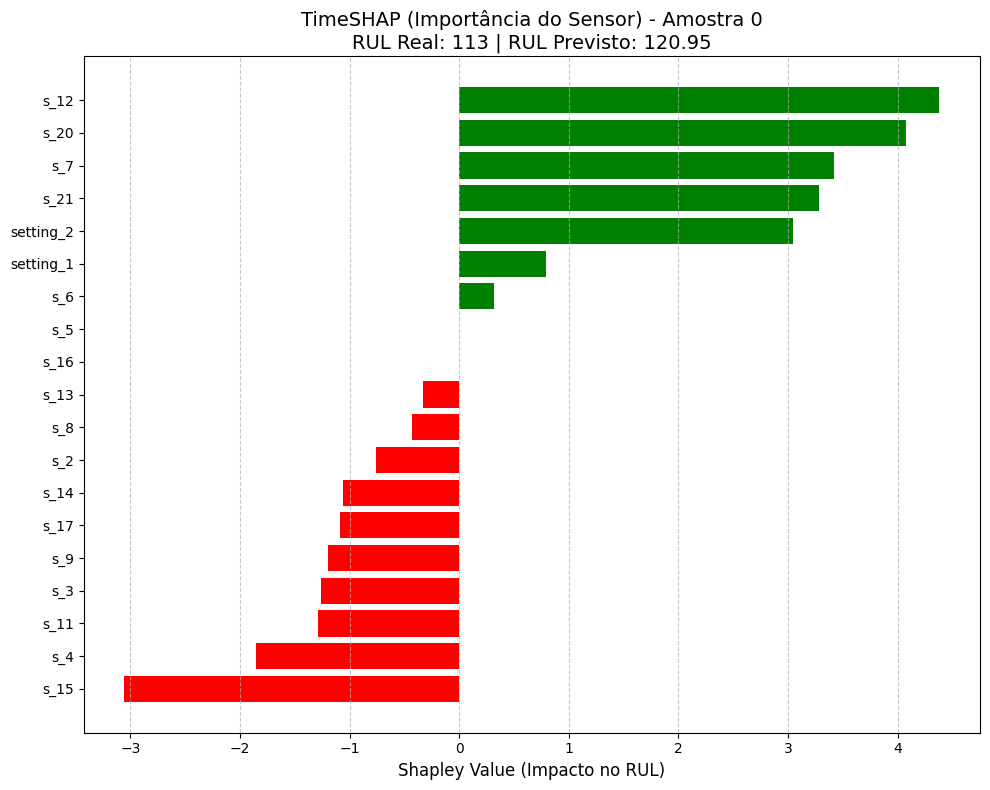

In [18]:
timeshap_explainer.plot_feature_importance(idx_teste, n_samples=3200)

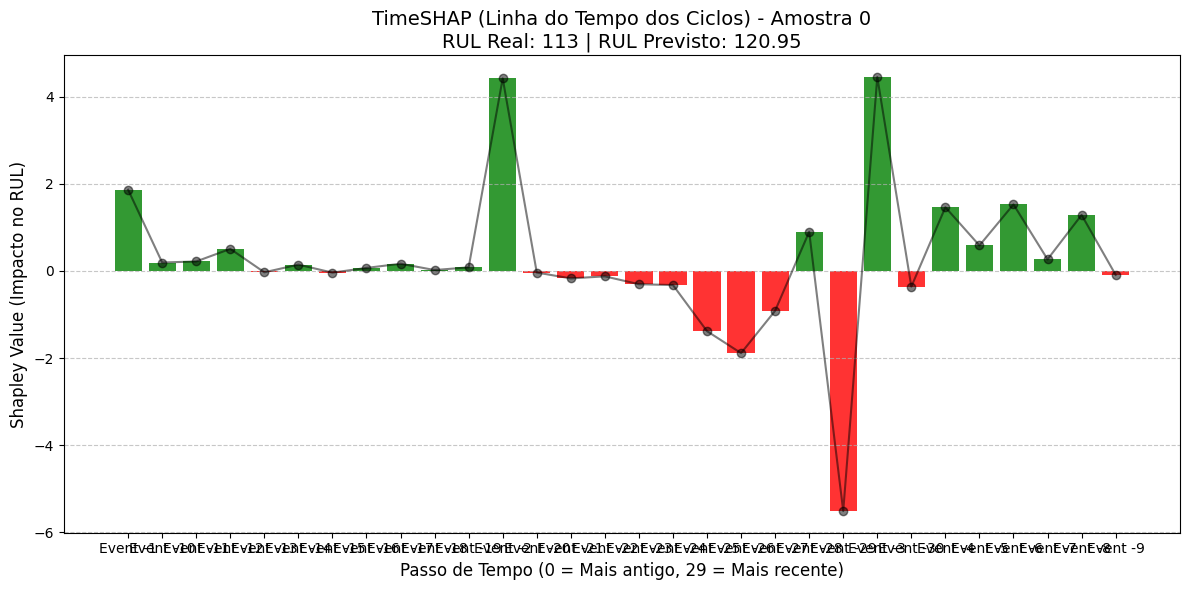

In [19]:
timeshap_explainer.plot_event_importance(idx_teste, n_samples=3200)

Calculando Pruning Temporal para a Amostra 0... (Tolerância: 5.0%)


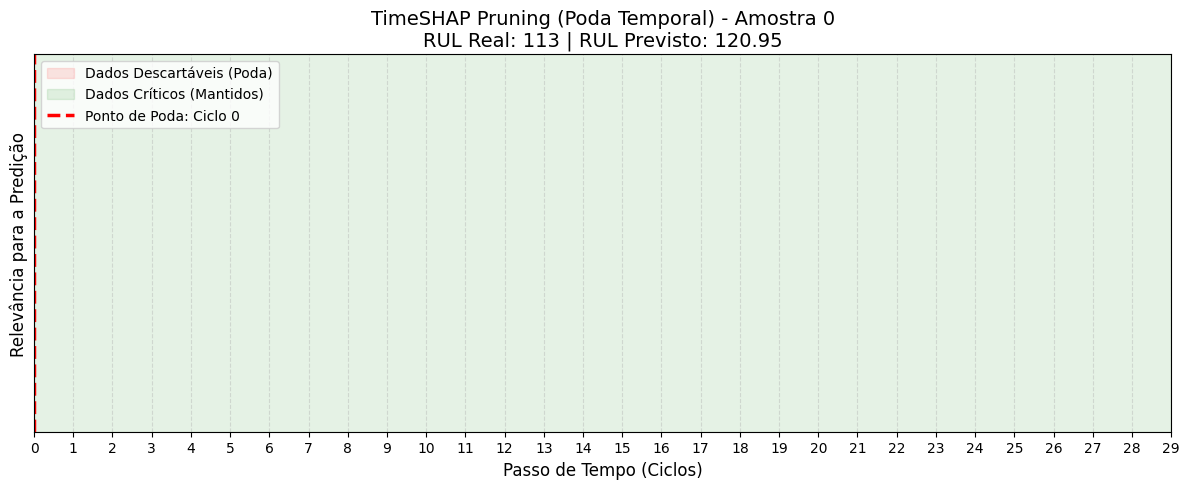

------------------------------------------------------------
RESULTADO DO PRUNING (Tolerância 5.0%):
-> Para manter a predição robusta, a CNN-LSTM precisa apenas dos ciclos 0 a 29.
-> Os ciclos iniciais de 0 a 0 não carregam impacto suficiente e podem ser podados.
------------------------------------------------------------


In [20]:
timeshap_explainer.plot_pruning(idx_teste, tolerance=0.05, n_samples=3200)

Calculando TimeSHAP Global para 10 amostras...


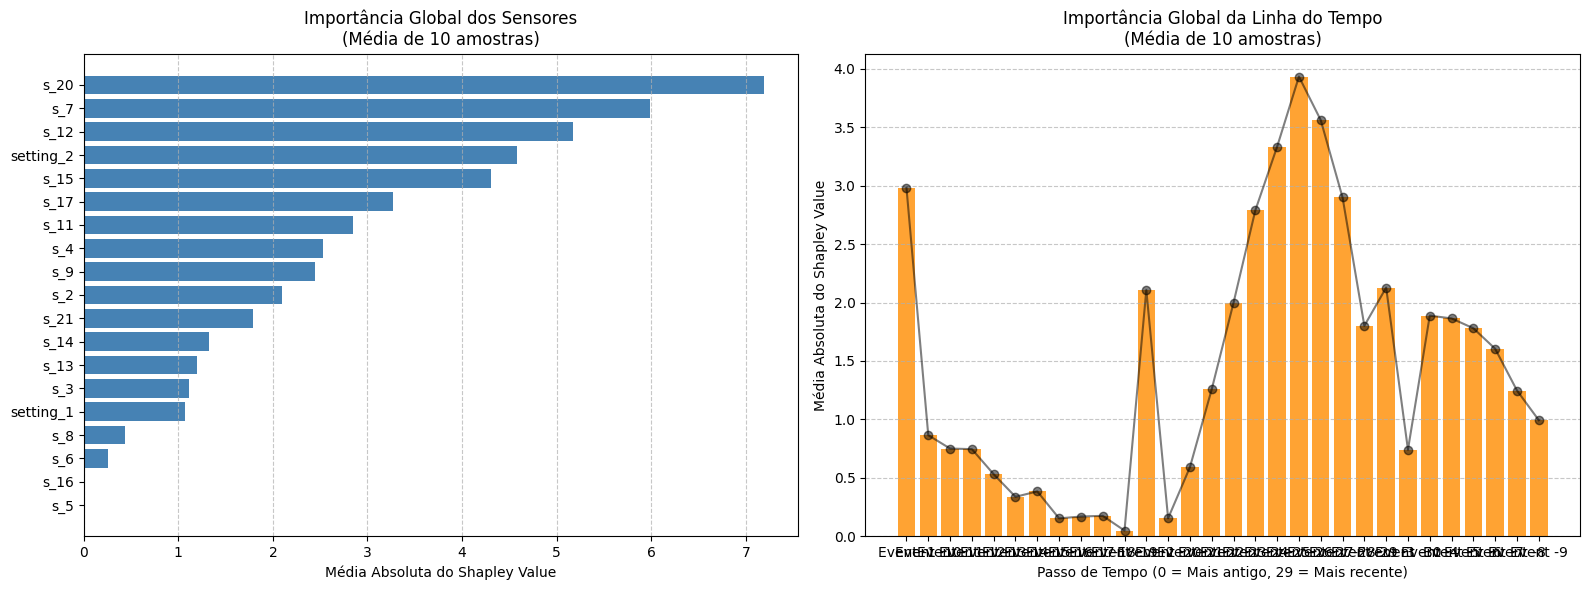

In [21]:
timeshap_explainer.plot_global_importance(num_instances=10, n_samples=3200)

## WindowSHAP

O `WindowSHAP` adapta a lógica do SHAP para lidar com séries temporais, agrupando os dados em **janelas de tempo**. Isso permite avaliar o impacto de blocos temporais inteiros (ex: de 5 em 5 ciclos) na predição.

In [22]:
from src.xai.xai_windowshapExplainer import WindowShapExplainer

windowshap_explainer = WindowShapExplainer(model_path, x_path, y_path)

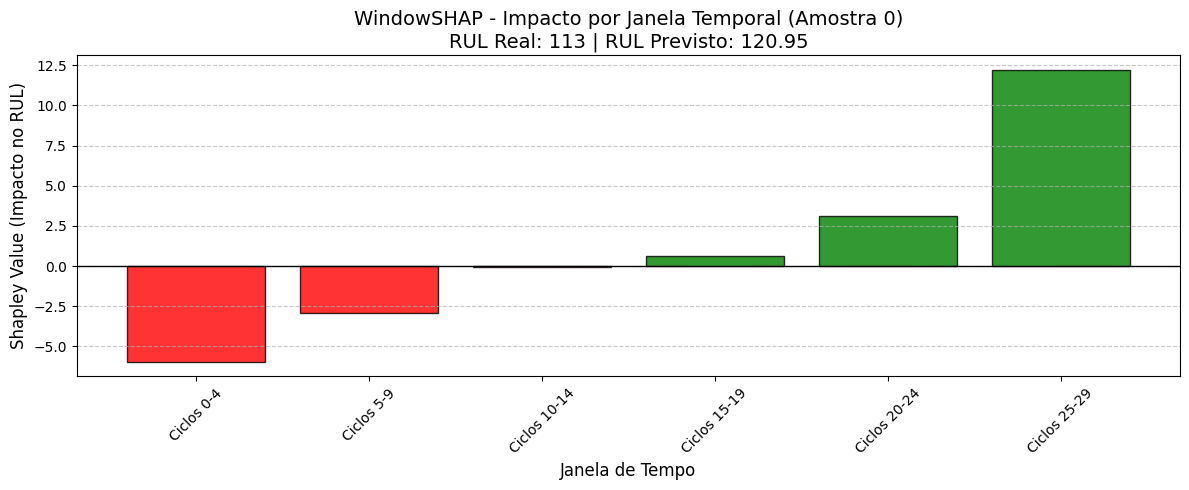

In [23]:
windowshap_explainer.plot_window_importance(idx_teste, n_samples=1000)

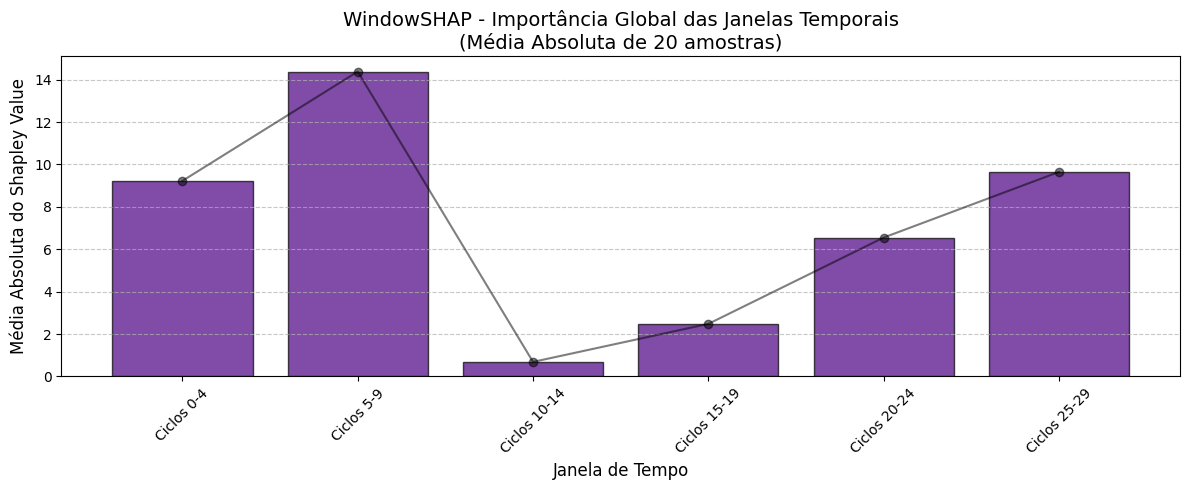

In [24]:
windowshap_explainer.plot_global_window_importance(num_instances=20, n_samples=1000)

## Grad-CAM

O `Grad-CAM` gera mapas de calor (*heatmaps*) extraindo os gradientes diretamente da última camada convolucional da rede. Ele mostra para quais **passos de tempo** os filtros da CNN direcionaram sua atenção antes de tomar a decisão final.

In [25]:
from src.xai.xaI_gradcamExplainer import GradCamExplainer

gradcam_explainer = GradCamExplainer(model_path, x_path, y_path)

Camada Convolucional identificada automaticamente: 'conv1d_30'


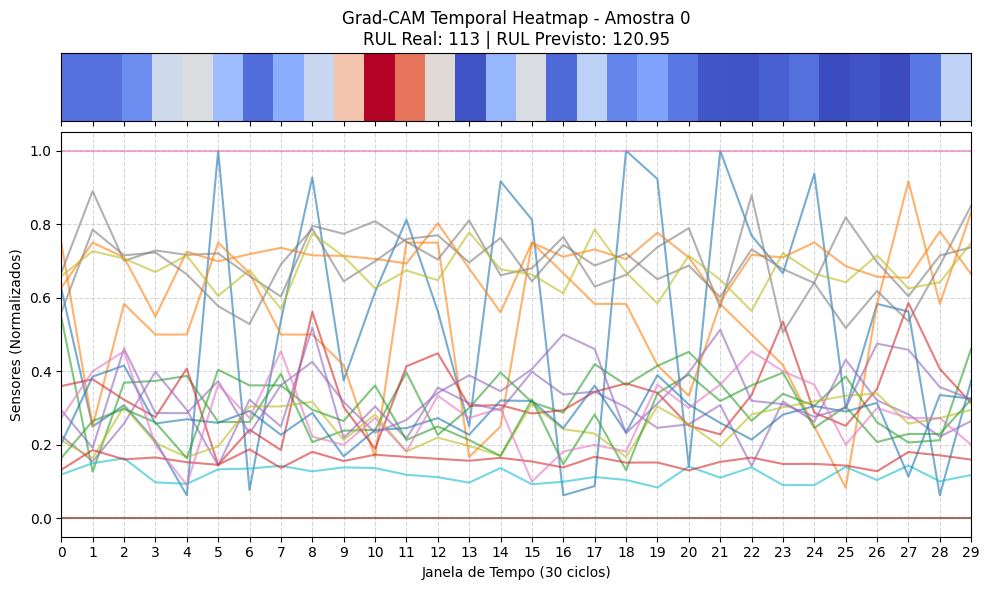

In [26]:
gradcam_explainer.plot_temporal_heatmap(idx_teste)

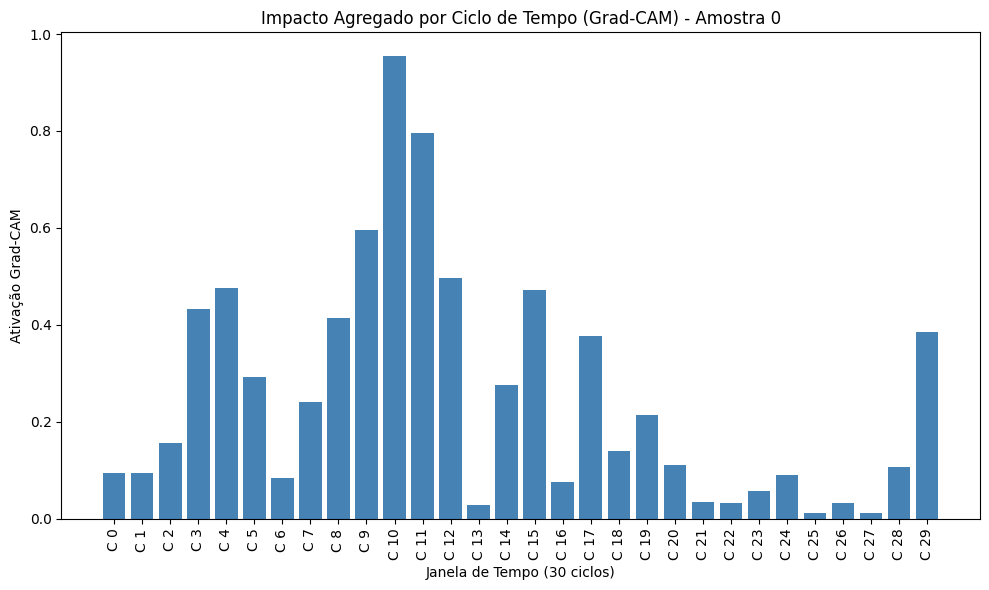

In [27]:
gradcam_explainer.plot_time_importance_bar(idx_teste)

Calculando Grad-CAM para 100 amostras (isso pode levar alguns segundos)...


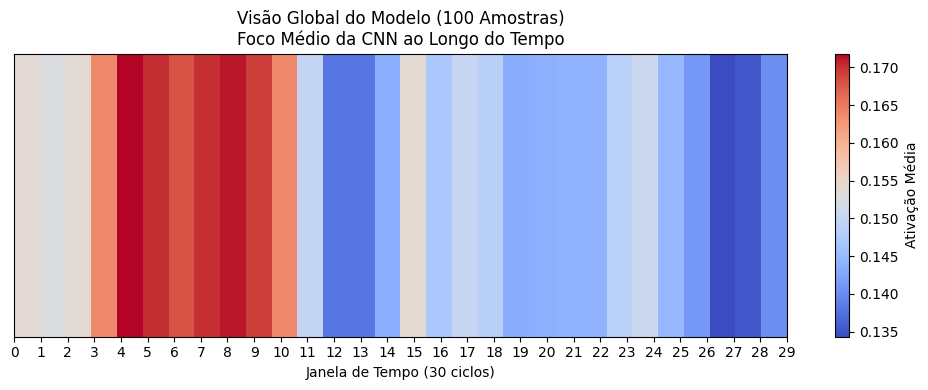

In [28]:
gradcam_explainer.plot_global_summary(num_samples=100)

## Saliency Maps

Os `Saliency Maps` (ou Vanilla Gradients) medem a sensibilidade da predição em relação à matriz de entrada. Eles geram um mapa evidenciando quais pequenas variações nos **dados brutos dos sensores** causariam o maior impacto e mudança no RUL previsto.

In [29]:
from src.xai.xai_saliencymapsExplainer import SaliencyMapsExplainer

saliency_explainer = SaliencyMapsExplainer(model_path, x_path, y_path)

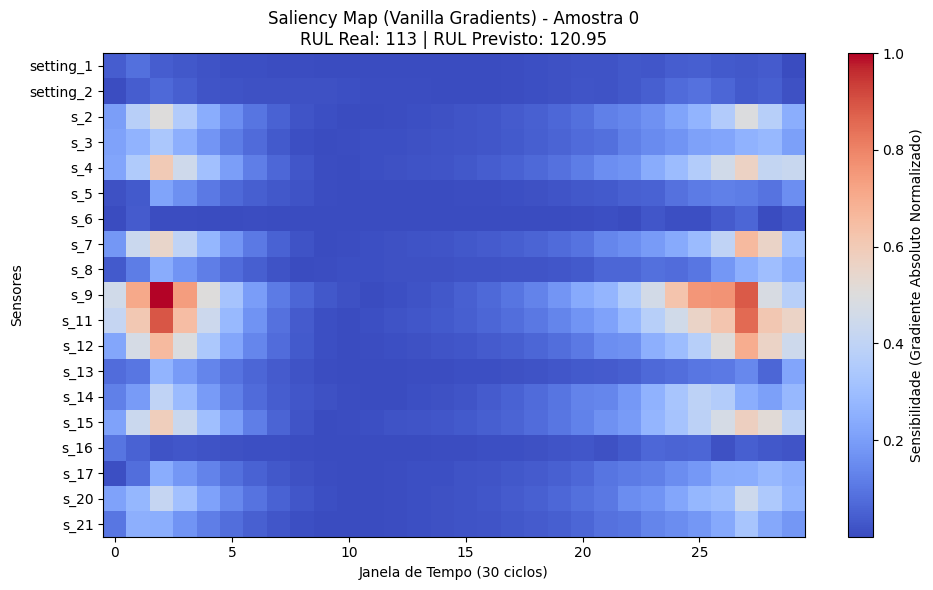

In [30]:
saliency_explainer.plot_temporal_heatmap(idx_teste)

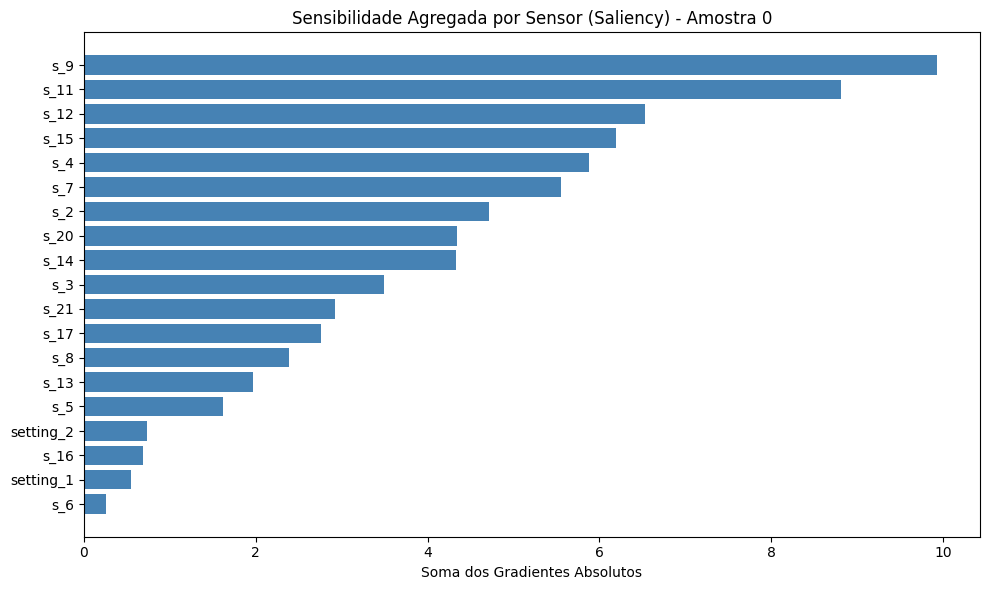

In [31]:
saliency_explainer.plot_sensor_importance_bar(idx_teste)

Calculando Saliency Maps para 100 amostras (isso pode levar alguns segundos)...


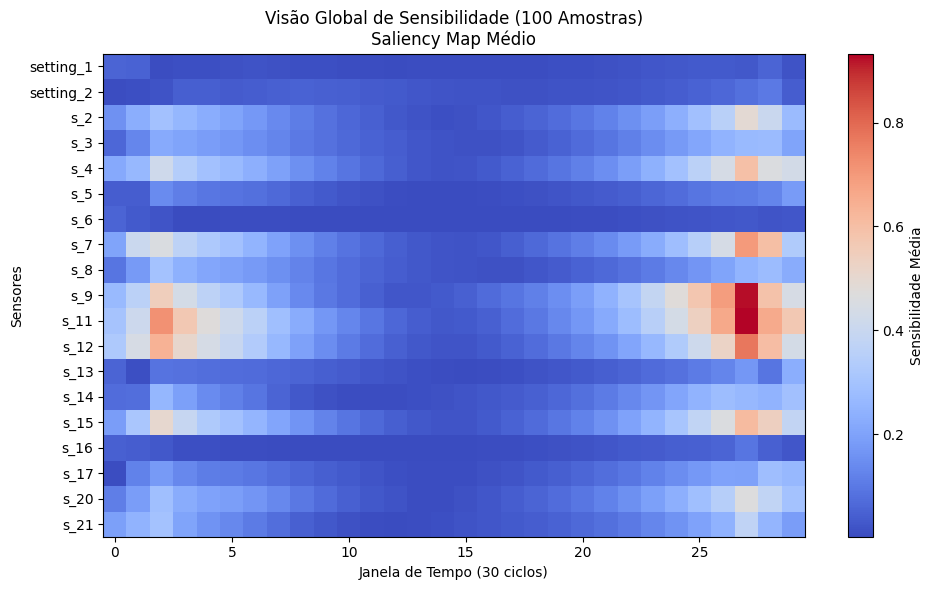

In [32]:
saliency_explainer.plot_global_summary(num_samples=100)